<a href="https://colab.research.google.com/github/Bromine185/NST_exp-/blob/main/03_distribution_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Quantitative analysis: how much distributional info does each loss actually match?

Notebooks 01 and 02 gave the *diagnosis* (features aren't Gaussian) and the *visual* (SW looks different from Gatys). This one quantifies the gap.

For each stylized output, we measure how close its VGG features are to the style's VGG features under three yardsticks:

1. **Gram matrix MSE** — what Gatys optimizes. Gatys wins by construction.
2. **Mean+std MSE** — what AdaIN optimizes.
3. **Sliced Wasserstein distance** — full-distribution mismatch. This is the honest yardstick because it's sensitive to *all* moments.

Also: 1D projection histograms of style features vs each stylized output's features, so you can see where each method fails to match the distribution.

**Run notebook 02 first**, or run the setup + stylization cells below (copied from 02) to produce the three outputs. This notebook assumes you have `out_gatys`, `out_adain`, `out_sw` in memory.

In [2]:
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.models as tvm
import torchvision.transforms as T
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)
torch.manual_seed(0); np.random.seed(0)

device: cuda


In [4]:

import os
if os.path.exists('/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'):
  style_i = '/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'
if os.path.exists('/content/lavender-field-sunset-near-valensole_268835-3910.avif'):
  content_i = '/content/lavender-field-sunset-near-valensole_268835-3910.avif'

class VGGFeatures(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = tvm.vgg19(weights=tvm.VGG19_Weights.IMAGENET1K_V1).features.eval()
        self.layer_ids = {'relu1_1':1,'relu2_1':6,'relu3_1':11,'relu4_1':20,'relu5_1':29}
        self.vgg = vgg
        for p in self.parameters(): p.requires_grad_(False)
    def forward(self, x):
        feats, last = {}, max(self.layer_ids.values())
        for i, layer in enumerate(self.vgg):
            x = layer(x)
            for n, idx in self.layer_ids.items():
                if i == idx: feats[n] = x
            if i >= last: break
        return feats

IMG_SIZE = 384
def load_image(path):
    tf = T.Compose([T.Resize(IMG_SIZE), T.CenterCrop(IMG_SIZE), T.ToTensor(),
                    T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
    return tf(Image.open(path).convert('RGB')).unsqueeze(0).to(device)
def denorm(x):
    m = torch.tensor([0.485,0.456,0.406], device=x.device).view(1,3,1,1)
    s = torch.tensor([0.229,0.224,0.225], device=x.device).view(1,3,1,1)
    return (x*s + m).clamp(0,1)

vgg = VGGFeatures().to(device)
content = load_image(
    '/content/lavender-field-sunset-near-valensole_268835-3910.avif'
)
style = load_image(
    '/content/Van_Gogh_-_Starry_Night_-_Google_Art_Project.jpg'
)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:02<00:00, 246MB/s]


## Cross-metric evaluation table

For every (stylized output, style) pair we compute all three distances. Each column is the yardstick, each row is the method. Diagonal wins by construction; the interesting numbers are off-diagonal — where a method that *wasn't* optimizing for a particular metric ended up on it.

In [23]:
with torch.no_grad():
    # Re-extract all features to ensure the table reflects the latest results
    sf   = vgg(style)
    fg   = vgg(out_gatys)
    fa   = vgg(out_adain)
    fs   = vgg(out_sw)
    fc   = vgg(content)

def all_metrics(gen_feats, sty_feats):
    with torch.no_grad():
        return dict(
            gram = gatys_loss(gen_feats, sty_feats).item(),
            adain = adain_loss(gen_feats, sty_feats).item(),
            sw   = sliced_wasserstein_loss(gen_feats, sty_feats, n_proj=256).item(),
        )

rows = {'content (baseline)': all_metrics(fc, sf),
        'Gatys output': all_metrics(fg, sf),
        'AdaIN output': all_metrics(fa, sf),
        'SW output':    all_metrics(fs, sf)}

print(f"{'method':22s} {'Gram MSE':>14s} {'AdaIN MSE':>14s} {'SW dist':>14s}")
print('-'*66)
for k, v in rows.items():
    print(f"{k:22s} {v['gram']:>14.4e} {v['adain']:>14.4e} {v['sw']:>14.4e}")

method                       Gram MSE      AdaIN MSE        SW dist
------------------------------------------------------------------
content (baseline)         2.0297e-04     8.9019e+00     6.2687e+00
Gatys output               1.8200e-06     5.1599e-01     5.4723e-01
AdaIN output               4.2351e-06     4.9030e-03     1.4720e-01
SW output                  1.4387e-05     8.7431e-01     4.2166e-01


In [24]:
# Style losses + optimizer
def gram(f):
    B, C, H, W = f.shape
    F_ = f.reshape(B, C, H*W)
    return (F_ @ F_.transpose(1,2)) / (C*H*W)

def gatys_loss(gen, sty):
    return sum(F.mse_loss(gram(gen[l]), gram(sty[l])) for l in sty)

def adain_loss(gen, sty):
    total = 0
    for l in sty:
        g, s = gen[l], sty[l]
        total = total + F.mse_loss(g.mean([2,3]), s.mean([2,3])) \
                     + F.mse_loss(g.std([2,3]),  s.std([2,3]))
    return total

def sliced_wasserstein_loss(gen, sty, n_proj=64):
    total = 0
    for l in sty:
        g, s = gen[l], sty[l]
        C = g.shape[1]
        g_flat = g.reshape(C, -1).T
        s_flat = s.reshape(C, -1).T
        V = torch.randn(C, n_proj, device=g.device)
        V = V / V.norm(dim=0, keepdim=True)
        gp, sp = g_flat @ V, s_flat @ V
        gs, _ = gp.sort(dim=0)
        ss, _ = sp.sort(dim=0)
        total = total + F.mse_loss(gs, ss)
    return total

def stylize(content, style, vgg, loss_fn, style_w, content_w=1.0,
            content_layer='relu4_1', n_iter=250, tag=''):
    gen = content.clone().requires_grad_(True)
    sty_feats = {k: v.detach() for k, v in vgg(style).items()}
    con_feats = {k: v.detach() for k, v in vgg(content).items()}
    opt = torch.optim.LBFGS([gen], lr=1.0, max_iter=n_iter,
                             line_search_fn='strong_wolfe')
    step = [0]
    def closure():
        opt.zero_grad()
        gf = vgg(gen)
        sL = loss_fn(gf, sty_feats)
        cL = F.mse_loss(gf[content_layer], con_feats[content_layer])
        L = style_w*sL + content_w*cL
        L.backward()
        step[0] += 1
        if step[0] % 40 == 0:
            print(f'  [{tag}] step {step[0]:4d}  style={sL.item():.3e}  content={cL.item():.3e}')
        return L
    opt.step(closure)
    return gen.detach()

print('--- Gatys ---')
out_gatys = stylize(content, style, vgg, gatys_loss, 1e6, tag='gatys')
print('--- AdaIN ---')
out_adain = stylize(content, style, vgg, adain_loss,  1e2, tag='adain')
print('--- SW ---')
out_sw    = stylize(content, style, vgg,
                     lambda g,s: sliced_wasserstein_loss(g, s, n_proj=64),
                     1e3, tag='sw')

--- Gatys ---
  [gatys] step   40  style=4.300e-06  content=5.642e+00
  [gatys] step   80  style=2.260e-06  content=4.668e+00
  [gatys] step  120  style=2.019e-06  content=4.406e+00
  [gatys] step  160  style=1.918e-06  content=4.287e+00
  [gatys] step  200  style=1.864e-06  content=4.219e+00
  [gatys] step  240  style=1.833e-06  content=4.173e+00
--- AdaIN ---
  [adain] step   40  style=1.738e-01  content=9.661e+00
  [adain] step   80  style=6.071e-02  content=8.475e+00
  [adain] step  120  style=2.440e-02  content=7.755e+00
  [adain] step  160  style=1.169e-02  content=7.213e+00
  [adain] step  200  style=7.779e-03  content=6.863e+00
  [adain] step  240  style=5.694e-03  content=6.650e+00
--- SW ---


In [25]:
def sliced_wasserstein_loss(gen, sty, n_proj=64):
    total = 0.0
    for i, l in enumerate(sty):
        g, s = gen[l], sty[l]
        C = g.shape[1]
        g_flat = g.reshape(C, -1).T
        s_flat = s.reshape(C, -1).T

        # Use a deterministic generator for L-BFGS line search to work
        gen_rng = torch.Generator(device=g.device)
        gen_rng.manual_seed(42 + i)
        V = torch.randn(C, n_proj, generator=gen_rng, device=g.device)

        V = V / (V.norm(dim=0, keepdim=True) + 1e-8)
        gp, sp = g_flat @ V, s_flat @ V
        gs, _ = gp.sort(dim=0)
        ss, _ = sp.sort(dim=0)
        loss = F.mse_loss(gs, ss)
        if torch.isnan(loss) or torch.isinf(loss):
            print("SW NaN/inf at layer", l)
        total = total + loss
    return total

In [11]:
def stylize(content, style, vgg, loss_fn, style_w, content_w=1.0,
            content_layer='relu4_1', n_iter=250, tag=''):
    gen = content.clone().requires_grad_(True)
    sty_feats = {k: v.detach() for k, v in vgg(style).items()}
    con_feats = {k: v.detach() for k, v in vgg(content).items()}
    opt = torch.optim.LBFGS([gen], lr=1.0, max_iter=n_iter,
                             line_search_fn='strong_wolfe')
    step = [0]
    def closure():
        opt.zero_grad()
        gf = vgg(gen)
        sL = loss_fn(gf, sty_feats)
        cL = F.mse_loss(gf[content_layer], con_feats[content_layer])
        L = style_w * sL + content_w * cL
        L.backward()
        step[0] += 1
        if step[0] % 40 == 0:
            print(f'  [{tag}] step {step[0]:4d}  style={sL.item():.3e}  content={cL.item():.3e}')
        return L
    opt.step(closure)
    return gen.detach()

In [26]:
print('--- SW ---')
out_sw    = stylize(content, style, vgg,
                     lambda g,s: sliced_wasserstein_loss(g, s, n_proj=64),
                     1e3, tag='sw')

--- SW ---
  [sw] step   40  style=1.101e-01  content=9.249e+00
  [sw] step   80  style=4.591e-02  content=9.083e+00
  [sw] step  120  style=2.414e-02  content=8.840e+00
  [sw] step  160  style=1.281e-02  content=8.647e+00
  [sw] step  200  style=7.469e-03  content=8.493e+00
  [sw] step  240  style=5.347e-03  content=8.386e+00


## What to look for in this table

- The `content (baseline)` row is how far the *original unstyled content* is from the style — every method should beat that on every metric.
- The `Gatys` row will have the smallest Gram MSE. That's tautological, it's what Gatys optimizes.
- The interesting cell is `Gatys row × SW column`. **How much worse is Gatys on the full-distribution metric than SW is?** That gap is a numerical estimate of the information Gatys ignores.
- If AdaIN's SW distance is similar to Gatys's, both are limited by their 2nd-order-moment view of the world. If SW's own SW distance is much lower, that's the empirical case for higher-moment matching.

## 1D projection histograms — where each method mismatches the distribution

Take features from one layer (`relu3_1` — middle of the network, deep enough to be style-ish, still enough spatial resolution to be interesting). Project the `HW × C` feature cloud onto a fixed random direction, then plot the 1D histogram for the style vs each stylized output.

If a method matched the full distribution, its blue histogram would sit on top of the black one. Where it diverges — a missing tail, a shifted mode, a spike at zero that isn't in the style — that's the moment structure the method fails to capture.

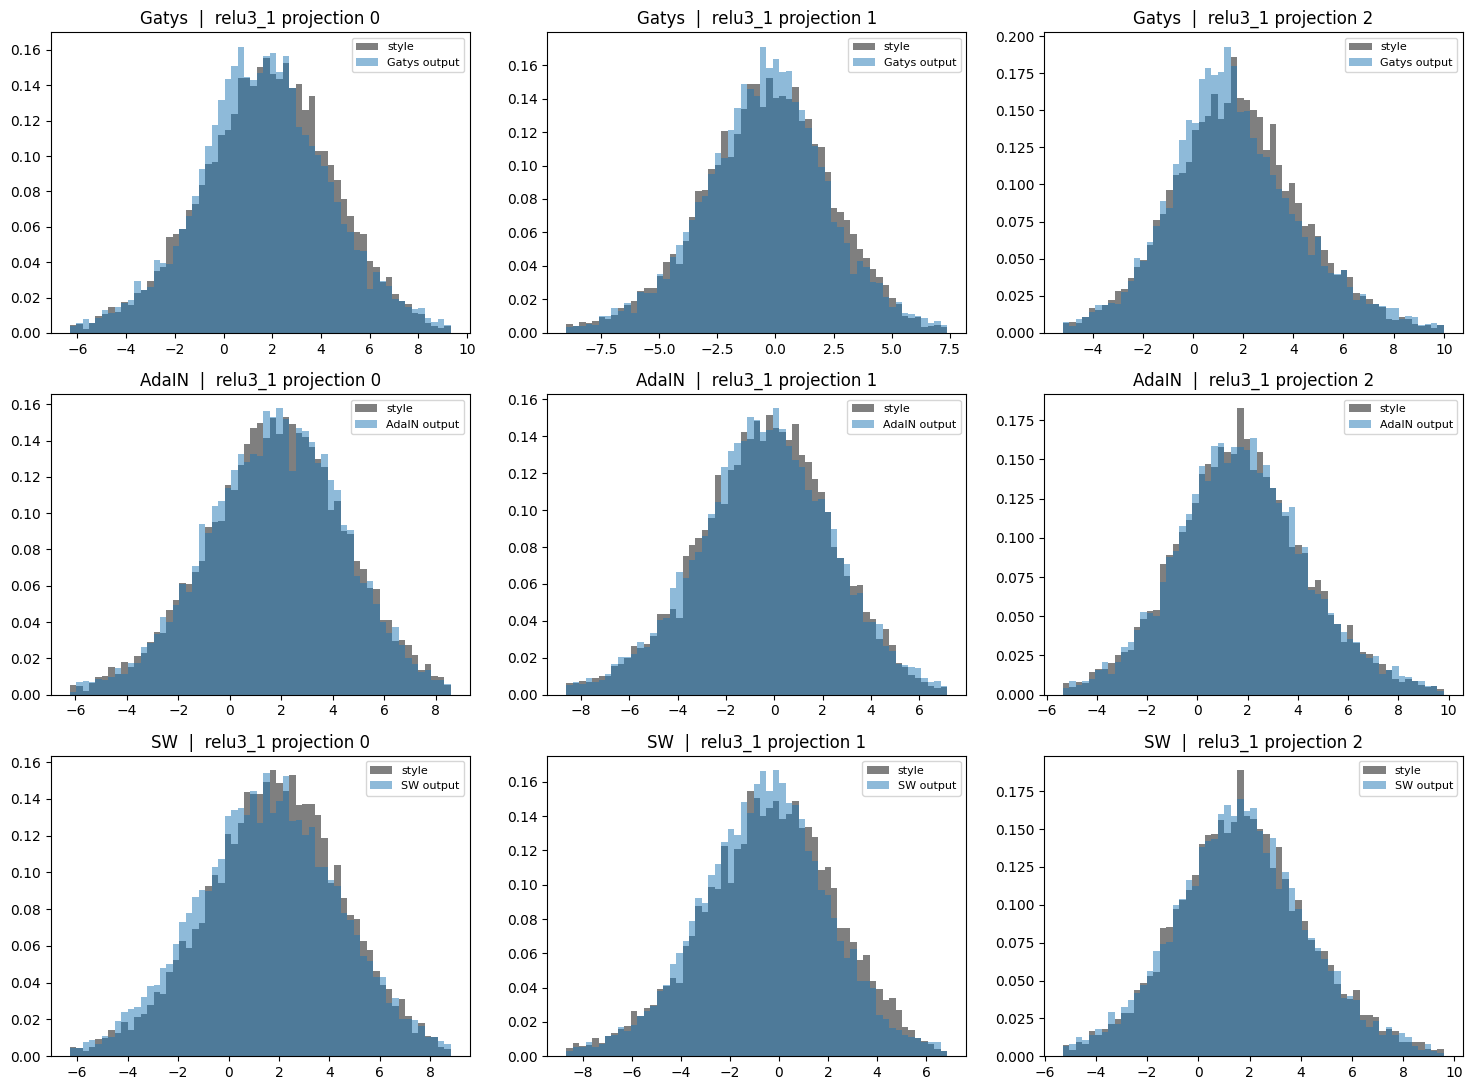

In [27]:
layer = 'relu3_1'
def proj_1d(f, direction):
    C = f.shape[1]
    return (f.reshape(C, -1).T @ direction).cpu().numpy()

# Re-extract all features to ensure we have the absolute latest trained values
with torch.no_grad():
    sf = vgg(style)
    fg = vgg(out_gatys)
    fa = vgg(out_adain)
    fs = vgg(out_sw)

    C = sf[layer].shape[1]
    # 3 fixed random projection directions
    dirs = torch.randn(C, 3, device=device)
    dirs = dirs / dirs.norm(dim=0, keepdim=True)

fig, ax = plt.subplots(3, 3, figsize=(15, 11))
for row, (name, feats) in enumerate([('Gatys', fg), ('AdaIN', fa), ('SW', fs)]):
    for col in range(3):
        d = dirs[:, col]
        s_p = proj_1d(sf[layer], d)
        g_p = proj_1d(feats[layer], d)
        a = ax[row, col]
        lo, hi = np.percentile(np.concatenate([s_p, g_p]), [0.5, 99.5])
        bins = np.linspace(lo, hi, 60)
        a.hist(s_p, bins=bins, alpha=0.5, density=True, color='k', label='style')
        a.hist(g_p, bins=bins, alpha=0.5, density=True, color='C0', label=f'{name} output')
        a.set_title(f'{name}  |  {layer} projection {col}')
        a.legend(fontsize=8)
plt.tight_layout()
plt.savefig('projection_histograms.png', dpi=120)
plt.show()

## Layer-wise SW distance — which layers each method matches best

Same yardstick (sliced W), broken down by VGG layer. Tells you *where* in the network each method is doing well or badly.

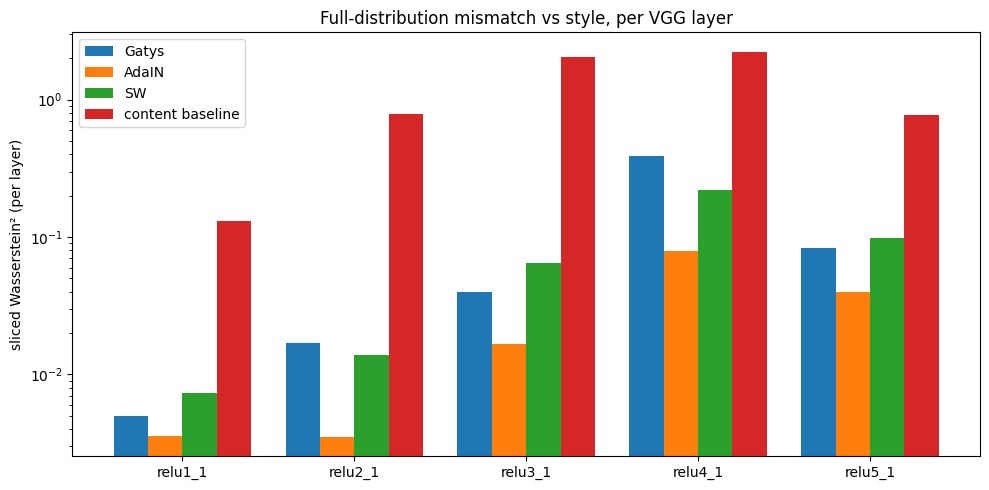

Gatys                relu1_1=4.965e-03  relu2_1=1.684e-02  relu3_1=4.013e-02  relu4_1=3.924e-01  relu5_1=8.264e-02
AdaIN                relu1_1=3.585e-03  relu2_1=3.515e-03  relu3_1=1.670e-02  relu4_1=7.984e-02  relu5_1=4.014e-02
SW                   relu1_1=7.301e-03  relu2_1=1.379e-02  relu3_1=6.502e-02  relu4_1=2.192e-01  relu5_1=9.786e-02
content baseline     relu1_1=1.310e-01  relu2_1=7.922e-01  relu3_1=2.029e+00  relu4_1=2.239e+00  relu5_1=7.746e-01


In [28]:
def sw_per_layer(gen, sty, n_proj=256):
    out = {}
    with torch.no_grad():
        for l in sty:
            g, s = gen[l], sty[l]
            C = g.shape[1]
            V = torch.randn(C, n_proj, device=g.device)
            V = V / V.norm(dim=0, keepdim=True)
            gp = (g.reshape(C, -1).T @ V).sort(dim=0)[0]
            sp = (s.reshape(C, -1).T @ V).sort(dim=0)[0]
            out[l] = F.mse_loss(gp, sp).item()
    return out

# Re-extract all features to ensure we have the absolute latest trained values
with torch.no_grad():
    sf = vgg(style)
    fg = vgg(out_gatys)
    fa = vgg(out_adain)
    fs = vgg(out_sw)
    fc = vgg(content)

per_layer = {'Gatys': sw_per_layer(fg, sf),
             'AdaIN': sw_per_layer(fa, sf),
             'SW':    sw_per_layer(fs, sf),
             'content baseline': sw_per_layer(fc, sf)}

layers = list(sf.keys())
x = np.arange(len(layers))
w = 0.2
plt.figure(figsize=(10,5))
for i, (name, d) in enumerate(per_layer.items()):
    plt.bar(x + (i-1.5)*w, [d[l] for l in layers], w, label=name)
plt.xticks(x, layers)
plt.ylabel('sliced Wasserstein² (per layer)')
plt.yscale('log')
plt.title('Full-distribution mismatch vs style, per VGG layer')
plt.legend()
plt.tight_layout()
plt.savefig('per_layer_sw.png', dpi=120)
plt.show()

for name, d in per_layer.items():
    print(f"{name:20s} " + '  '.join(f'{l}={d[l]:.3e}' for l in layers))

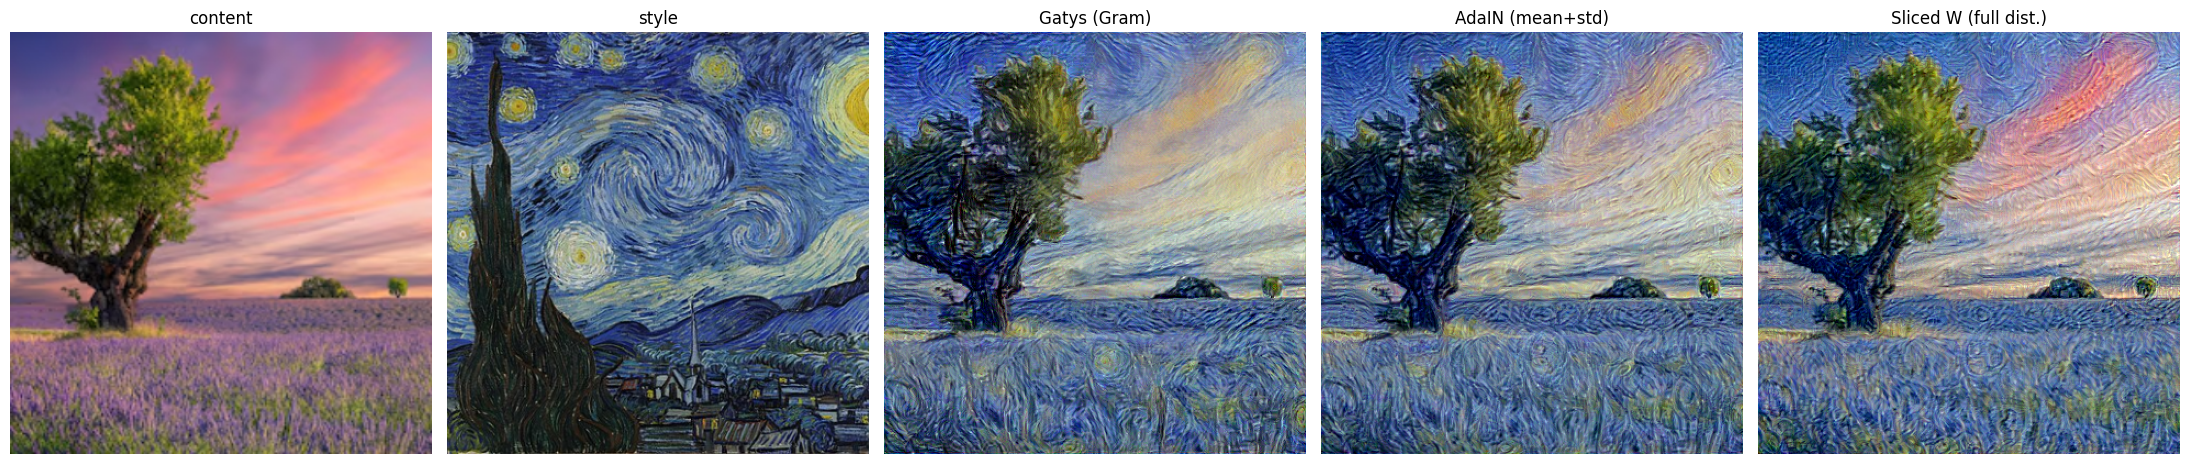

In [29]:
fig, ax = plt.subplots(1, 5, figsize=(22, 5))
for a, im, t in zip(ax,
                    [content, style, out_gatys, out_adain, out_sw],
                    ['content', 'style',
                     'Gatys (Gram)', 'AdaIN (mean+std)',
                     'Sliced W (full dist.)']):
    a.imshow(denorm(im).squeeze().permute(1,2,0).cpu().numpy())
    a.set_title(t); a.axis('off')
plt.tight_layout()
plt.savefig('style_bakeoff.png', dpi=120)
plt.show()

## The write-up section — what these results actually let you claim

This is the empirical spine for the argument in the WhatsApp thread. Concretely:

1. **From notebook 01**: the Gaussian assumption underlying Gram / AdaIN matching is empirically false at every VGG layer. Cite the `%chan Gaussian` numbers and the histograms.

2. **From notebook 02**: matching the full distribution (SW) produces visibly different outputs from matching only 1st + 2nd moments. So the non-Gaussianity matters — it's not a harmless approximation.

3. **From this notebook**: quantify the gap. The Gatys-row / SW-column number is how much distributional info Gatys is throwing away. The per-layer chart tells you *which* layers the second-order approximation breaks down hardest.

What this does **not** support: the specific claim that "higher-order tensors encoding higher-order statistics" is the right fix. A concrete 3rd-moment tensor is `O(C³)` and impractical. The literature answer — sliced Wasserstein, or the attention-based stylization methods like SANet / StyTR² — matches the distribution *implicitly* without ever forming an explicit high-order moment. That's the honest framing for the paper: not "they should have used bigger tensors," but "the moment-matching frame was the wrong frame; distribution-matching is."

Cite: Heitz et al., *A Sliced Wasserstein Loss for Neural Texture Synthesis*, CVPR 2021. Kolkin et al., *STROTSS*, CVPR 2019. Risser et al., *Stable and Controllable Neural Texture Synthesis*, 2017.